In [1]:
# Raghav Bharathan
# ECE 452
# Project 2 - Steps 4 and 5
# Professor Shaahin Angizi

In [2]:
# Imports and GPU check
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')

CUDA available: True
GPU: Tesla T4


In [3]:
# defining functions

def gemm_cublas(A, B, C):
    return torch.matmul(A, B) + C

def benchmark_cublas(size, iterations=10):
    A = torch.randn(size, size, dtype=torch.float32, device='cuda')
    B = torch.randn(size, size, dtype=torch.float32, device='cuda')
    C = torch.zeros(size, size, dtype=torch.float32, device='cuda')

    # This is for warmup - I heard CUDA has to do a lot of one-time setup to
    # load the cuBLAS kernels and allocate context, so hopefully this should
    # take that out of the equation for proper timing.
    _ = gemm_cublas(A, B, C)
    torch.cuda.synchronize()

    times = []
    for _ in range(iterations):
        start = torch.cuda.Event(enable_timing=True)
        end   = torch.cuda.Event(enable_timing=True)

        start.record()
        result = gemm_cublas(A, B, C)
        end.record()

        torch.cuda.synchronize()
        times.append(start.elapsed_time(end) / 1000)

    avg = sum(times) / iterations
    return times, avg



In [4]:
# Running the benchmark tests

sizes      = [128, 256, 512]
iterations = 10

print(f"{'Size':<12} {'Avg Time (s)':<16} {'Iterations'}")
print("-" * 38)

all_results = {}
for size in sizes:
    times, avg = benchmark_cublas(size, iterations)
    all_results[size] = {'times': times, 'avg': avg}
    print(f'{size}x{size:<8} {avg:<16.6f} {iterations}')

Size         Avg Time (s)     Iterations
--------------------------------------
128x128      0.000073         10
256x256      0.000078         10
512x512      0.000166         10


In [5]:
# Doing it per iteration

for size in sizes:
    print(f'\n{size}x{size}:')
    for i, t in enumerate(all_results[size]['times']):
        print(f'  Iter {i+1:2d}: {t:.6f}s')
    print(f'  Avg:    {all_results[size]["avg"]:.6f}s')


128x128:
  Iter  1: 0.000213s
  Iter  2: 0.000067s
  Iter  3: 0.000051s
  Iter  4: 0.000047s
  Iter  5: 0.000094s
  Iter  6: 0.000059s
  Iter  7: 0.000047s
  Iter  8: 0.000057s
  Iter  9: 0.000048s
  Iter 10: 0.000045s
  Avg:    0.000073s

256x256:
  Iter  1: 0.000106s
  Iter  2: 0.000079s
  Iter  3: 0.000074s
  Iter  4: 0.000074s
  Iter  5: 0.000071s
  Iter  6: 0.000072s
  Iter  7: 0.000076s
  Iter  8: 0.000075s
  Iter  9: 0.000072s
  Iter 10: 0.000080s
  Avg:    0.000078s

512x512:
  Iter  1: 0.000181s
  Iter  2: 0.000164s
  Iter  3: 0.000168s
  Iter  4: 0.000163s
  Iter  5: 0.000163s
  Iter  6: 0.000168s
  Iter  7: 0.000162s
  Iter  8: 0.000164s
  Iter  9: 0.000162s
  Iter 10: 0.000163s
  Avg:    0.000166s


In [6]:
# As we can see, the GPU times are so much better compared to CPU.
# I'll analyze this more in the report.


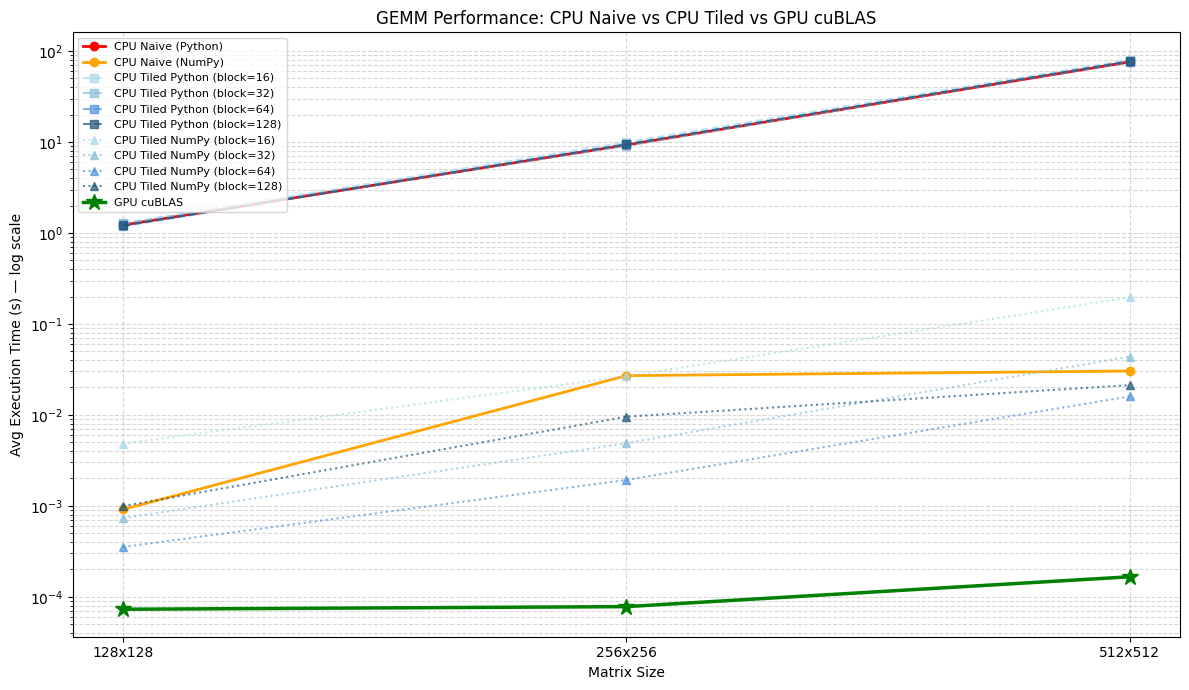

Plot saved: gemm_comparison.png


In [ ]:
# Part 5: Final Comparison
import matplotlib.pyplot as plt
import numpy as np

sizes = [128, 256, 512]

# CPU Naive (Python) 
cpu_naive_python = [1.2225, 9.2633, 75.9566]

# CPU Naive (NumPy) 
cpu_naive_numpy = [0.000913, 0.027003, 0.030352]

# CPU Tiled Python (best block per size was block 64) 
tiled_python = {
    16:  [1.2762,  9.9473,  80.0421],
    32:  [1.2703,  9.0732,  77.8905],
    64:  [1.1884,  9.4734,  75.7319],
    128: [1.2101,  9.3861,  77.2036],
}

# CPU Tiled NumPy (best block per size was block 64)
tiled_numpy = {
    16:  [0.004827, 0.026627, 0.195474],
    32:  [0.000736, 0.004878, 0.043756],
    64:  [0.000353, 0.001928, 0.015951],
    128: [0.000994, 0.009544, 0.021241],
}

# cuBLAS 
gpu_cublas = [0.000073, 0.000078, 0.000166]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(sizes))
colors_tiled = ['#a8d8ea', '#87bdd8', '#4a90d9', '#1a5276']

# CPU Naive
ax.plot(x, cpu_naive_python, marker='o', color='red',    linewidth=2, label='CPU Naive (Python)')
ax.plot(x, cpu_naive_numpy,  marker='o', color='orange', linewidth=2, label='CPU Naive (NumPy)')

# CPU Tiled Python (all block sizes)
for i, bs in enumerate([16, 32, 64, 128]):
    ax.plot(x, tiled_python[bs], marker='s', linestyle='--',
            color=colors_tiled[i], linewidth=1.5, alpha=0.7, label=f'CPU Tiled Python (block={bs})')

# CPU Tiled NumPy (all block sizes)
for i, bs in enumerate([16, 32, 64, 128]):
    ax.plot(x, tiled_numpy[bs], marker='^', linestyle=':',
            color=colors_tiled[i], linewidth=1.5, alpha=0.7, label=f'CPU Tiled NumPy (block={bs})')

# GPU cuBLAS
ax.plot(x, gpu_cublas, marker='*', color='green', linewidth=2.5, markersize=12, label='GPU cuBLAS')

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([f'{s}x{s}' for s in sizes])
ax.set_xlabel('Matrix Size')
ax.set_ylabel('Avg Execution Time (s) — log scale')
ax.set_title('GEMM Performance: CPU Naive vs CPU Tiled vs GPU cuBLAS')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('gemm_comparison.png', dpi=150)
plt.show()
print('Plot saved: gemm_comparison.png')
